## 3장 2강: 로지스틱 회귀와 교차 검증

### 1. 로지스틱 회귀: 선형 회귀로 분류를 해결하는 마법
#### 1.5 범주형 데이터 전처리: 원핫 인코딩의 명과 암

원핫 인코딩 실습

실습에 필요한 도구 불러오기

In [15]:
from sklearn.preprocessing import OneHotEncoder

간단한 가상의 과일 범주 데이터를 준비합니다.

In [16]:
data = pd.DataFrame({'과일': ['사과', '바나나', '딸기', '바나나']})
data

,과일
0,사과
1,바나나
2,딸기
3,바나나


원핫 인코딩 변환

In [17]:
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(data[['과일']])

encoded_data

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.]])

변환 결과를 보기 좋게 판다스 데이터프레임으로 만들어 출력합니다.

### 3. 붓꽃 데이터(Iris) 이진 및 다중 분류 실습
#### 3.1 데이터 불러오기 및 학습 준비

실습에 필요한 도구 불러오기

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

붓꽃 데이터셋(Iris.csv) 불러오기

In [19]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [20]:
df['Species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

실습 1. 이진 분류용 데이터 구성

In [21]:
df_binary = df[df['Species'].isin(['Iris-setosa', 'Iris-versicolor'])].copy()

X_binary = df_binary[['PetalLengthCm', 'PetalWidthCm']]

y_binary = df_binary['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1})

X_bin_train, X_bin_test, y_bin_train, y_bin_test = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

X_binary.head()

,PetalLengthCm,PetalWidthCm
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [22]:
y_binary.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

In [23]:
# 이진 분류 모델 학습
binary_model = LogisticRegression()
binary_model.fit(X_bin_train, y_bin_train)

bin_test_preds = binary_model.predict(X_bin_test)

print(bin_test_preds)
print(y_bin_test.values)
bin_accuracy = accuracy_score(y_bin_test, bin_test_preds)
print(f"이진 분류 테스트 정확도: {bin_accuracy:.4f}")

[1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]
[1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]
이진 분류 테스트 정확도: 1.0000


실습 2. 다중 분류용 데이터 구성

In [25]:
df['Species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [28]:
X_multi = df[['PetalLengthCm', 'PetalWidthCm']]
y_multi = df['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})

X_multi.head()

,PetalLengthCm,PetalWidthCm
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [29]:
y_multi.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

#### 3.2 모델 학습 및 결정 경계(Decision Boundary) 시각화
모델 학습 및 교차 검증하기

In [30]:
# 다중 분류 훈련세트, 테스트 세트
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

In [ ]:
# 다중 분류 모델 학습
multi_model = LogisticRegression()

# 교차 검증(KFold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(multi_model, X_multi_train, y_multi_train, cv=kf)
print("cv_scores:", cv_scores)
print("교차 검증 정확도 평균: %.4f" % cv_scores.mean())

multi_model.fit(X_multi_train, y_multi_train)

multi_test_preds = multi_model.predict(X_multi_test)
print("예측한 값:", multi_test_preds)
print("원래 값:", y_multi_test.values)

multi_accuracy = accuracy_score(y_multi_test, multi_test_preds)

print(f"정확도: {multi_accuracy:.4f}")

cv_scores: [0.91666667 0.95833333 0.95833333 1.         0.95833333]
교차 검증 정확도 평균: 0.9583
예측한 값: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
원래 값: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
정확도: 0.9667


두 가지 실습 결과를 한눈에 비교하기 위한 Matplotlib 시각화

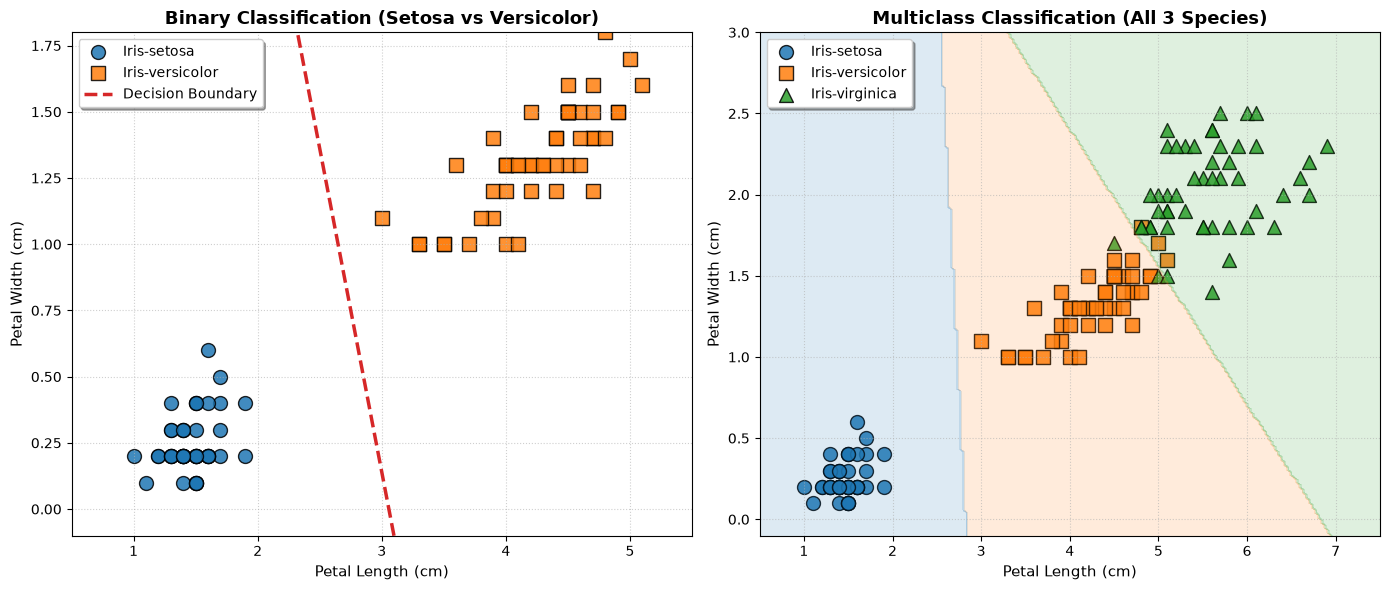

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# [왼쪽 플롯] 이진 분류 선형 결정 경계선 그리기
ax1 = axes[0]  
colors_binary = ['#1F77B4', '#FF7F0E']  
markers_binary = ['o', 's']
species_binary = ['Iris-setosa', 'Iris-versicolor']

for species, color, marker in zip(species_binary, colors_binary, markers_binary):
    subset = df_binary[df_binary['Species'] == species]
    ax1.scatter(subset['PetalLengthCm'], subset['PetalWidthCm'], label=species, color=color, marker=marker, s=100, edgecolor='black', alpha=0.85)

# 선형 분류 경계면 공식 유도: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b)/w2
w1, w2 = binary_model.coef_[0][0], binary_model.coef_[0][1]
b = binary_model.intercept_[0]

x_vals = np.linspace(0.8, 5.2, 100)
y_vals = -(w1 * x_vals + b) / w2
ax1.plot(x_vals, y_vals, '--', color='#D62728', linewidth=2.5, label='Decision Boundary')

ax1.set_title("Binary Classification (Setosa vs Versicolor)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Petal Length (cm)", fontsize=11)
ax1.set_ylabel("Petal Width (cm)", fontsize=11)
ax1.set_xlim(0.5, 5.5)
ax1.set_ylim(-0.1, 1.8)
ax1.legend(loc='upper left', frameon=True, shadow=True)
ax1.grid(True, linestyle=':', alpha=0.6)


# [오른쪽 플롯] 다중 분류 영역 맵 시각화
ax2 = axes[1]
colors_multi = {'Iris-setosa': '#1F77B4', 'Iris-versicolor': '#FF7F0E', 'Iris-virginica': '#2CA02C'}
markers_multi = {'Iris-setosa': 'o', 'Iris-versicolor': 's', 'Iris-virginica': '^'}

for species in ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']:
    subset = df[df['Species'] == species]
    ax2.scatter(subset['PetalLengthCm'], subset['PetalWidthCm'], label=species, color=colors_multi[species], marker=markers_multi[species], s=100, edgecolor='black', alpha=0.85)

# 가로축과 세로축 격자를 촘촘히 쪼개 전 구역에 소프트맥스 예측 결과 칠하기
xx, yy = np.meshgrid(np.linspace(0.5, 7.5, 200), np.linspace(-0.1, 3.0, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]


grid_df = pd.DataFrame(grid_points, columns=['PetalLengthCm', 'PetalWidthCm'])
Z_pred = multi_model.predict(grid_df)

# 클래스 이름을 예측 컬러 번호(0, 1, 2)로 전처리 변환
species_to_num = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
#Z_num = np.array([species_to_num[item] for item in Z_pred]).reshape(xx.shape)
Z_num = np.array(Z_pred).reshape(xx.shape)
# 결정 구역에 예쁜 투명도를 주어 영역 채우기
custom_cmap = ListedColormap(['#1F77B4', '#FF7F0E', '#2CA02C'])
ax2.contourf(xx, yy, Z_num, alpha=0.15, cmap=custom_cmap)

ax2.set_title("Multiclass Classification (All 3 Species)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Petal Length (cm)", fontsize=11)
ax2.set_ylabel("Petal Width (cm)", fontsize=11)
ax2.set_xlim(0.5, 7.5)
ax2.set_ylim(-0.1, 3.0)
ax2.legend(loc='upper left', frameon=True, shadow=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()